In [59]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [60]:
# reading dataset here using pandas module 
df = pd.read_csv('dataset/assignment-1.csv')

In [61]:
df.head()

,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
0,2,40,38,3,62
1,5,60,42,6,78
2,1,20,35,2,55
3,8,80,45,8,88
4,50,50,40,5,72


In [62]:
df.describe()

,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,9.400000,54.000000,41.100000,5.400000,73.900000
std,14.561746,24.698178,4.557046,2.366432,12.939603
min,1.000000,20.000000,35.000000,2.000000,55.000000
25%,2.250000,32.500000,37.250000,3.250000,62.750000
50%,5.500000,55.000000,41.000000,5.500000,75.000000
75%,7.750000,73.750000,44.750000,7.000000,84.250000
max,50.000000,90.000000,48.000000,9.000000,92.000000


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Experience (yrs)    10 non-null     int64
 1   Training Hours      10 non-null     int64
 2   Working Hours       10 non-null     int64
 3   Projects            10 non-null     int64
 4   Productivity Score  10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [64]:
# printing all columns of csv
df.columns

Index(['Experience (yrs)', 'Training Hours', 'Working Hours', 'Projects',
       'Productivity Score'],
      dtype='object')

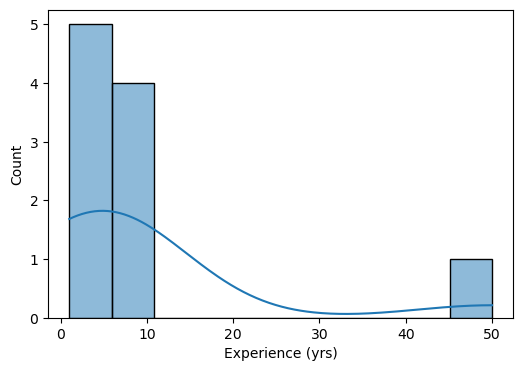

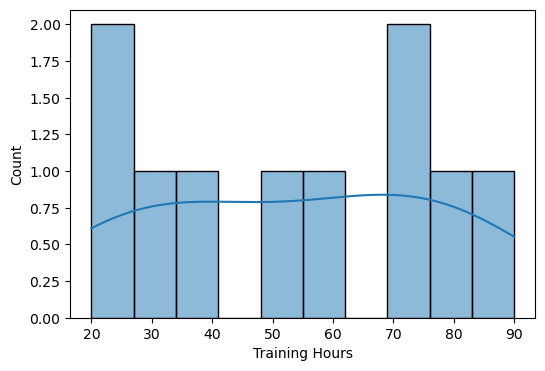

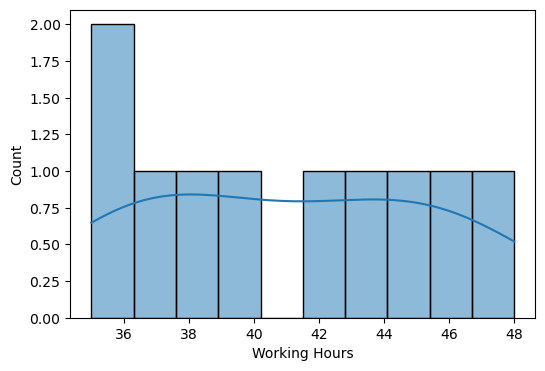

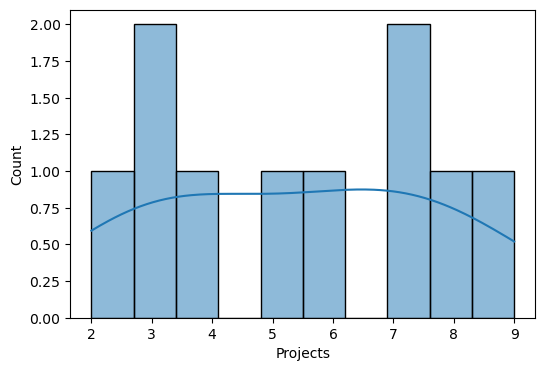

In [65]:
# just checking here data distribution, it is not required here, but as best practice, we can understand data flow
numeric_column = ['Experience (yrs)', 'Training Hours', 'Working Hours', 'Projects']
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=10)

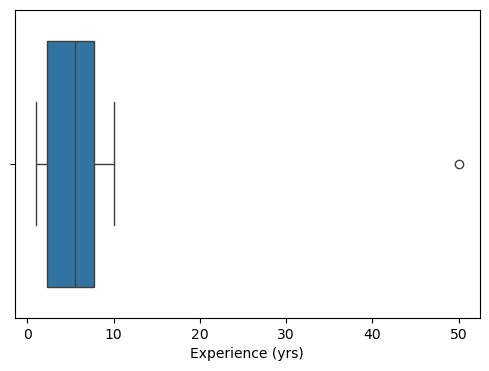

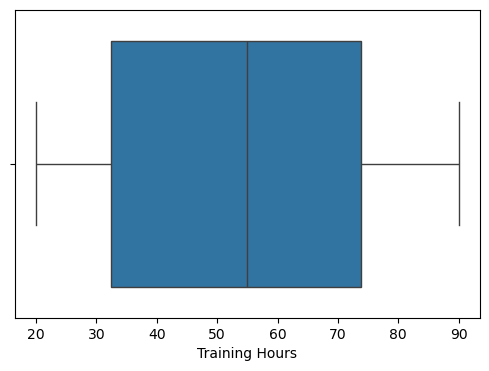

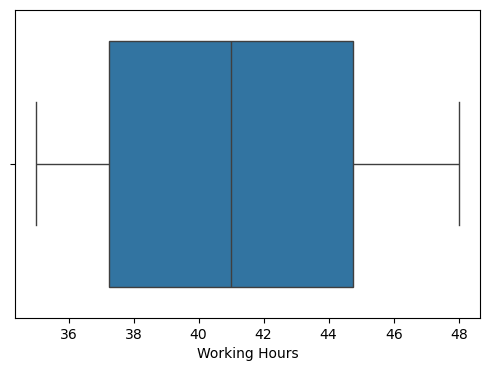

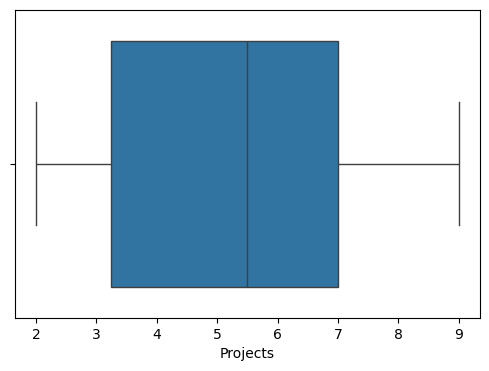

In [66]:
# Now I'm checking, is there outliner in data?
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

In [67]:
# We found one data point as an outlier, which you can see above the experience columns
# Now we need to remove outliers from the experience columns using IQR.

Q1 = df['Experience (yrs)'].quantile(0.25)
Q3 = df['Experience (yrs)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [68]:
#Filter data
cleaned_df = df[(df["Experience (yrs)"] >= lower_bound) & (df["Experience (yrs)"] <= upper_bound)]

In [69]:
cleaned_df.describe() # we can see below the data we have removed outliers

,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
count,9.000000,9.000000,9.000000,9.000000,9.000000
mean,4.888889,54.444444,41.222222,5.444444,74.111111
std,3.100179,26.153925,4.816061,2.505549,13.706244
min,1.000000,20.000000,35.000000,2.000000,55.000000
25%,2.000000,30.000000,37.000000,3.000000,62.000000
50%,5.000000,60.000000,42.000000,6.000000,78.000000
75%,7.000000,75.000000,45.000000,7.000000,85.000000
max,10.000000,90.000000,48.000000,9.000000,92.000000


<Axes: xlabel='Experience (yrs)'>

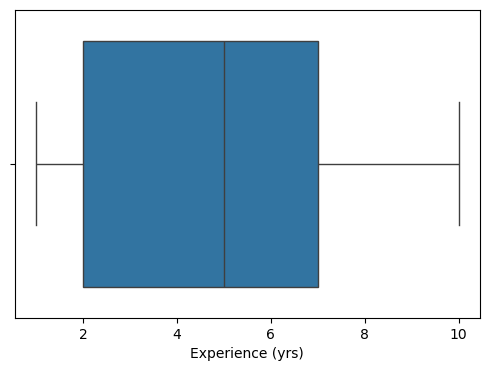

In [70]:
plt.figure(figsize=(6,4))
sns.boxplot(x = cleaned_df["Experience (yrs)"])

<Axes: >

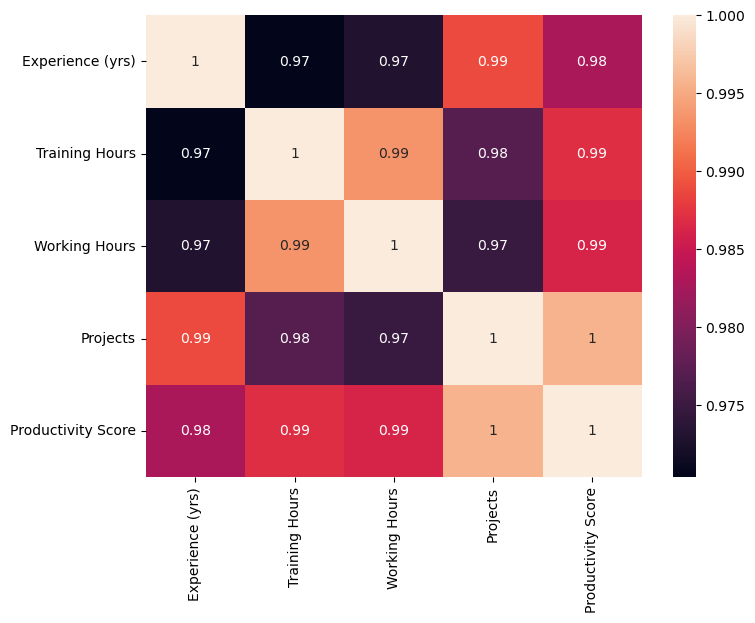

In [71]:
plt.figure(figsize=(8,6))
sns.heatmap(cleaned_df.corr(numeric_only=True), annot=True) # check co-relation between columns

In [72]:
cleaned_df[['Experience (yrs)', 'Training Hours', 'Working Hours', 'Projects', 'Productivity Score']].corr()

,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
Experience (yrs),1.000000,0.970384,0.973017,0.988787,0.982869
Training Hours,0.970384,1.000000,0.993490,0.977077,0.987021
Working Hours,0.973017,0.993490,1.000000,0.974891,0.986171
Projects,0.988787,0.977077,0.974891,1.000000,0.995713
Productivity Score,0.982869,0.987021,0.986171,0.995713,1.000000


In [73]:
X = cleaned_df[['Experience (yrs)', 'Training Hours', 'Working Hours', 'Projects']]
y = cleaned_df["Productivity Score"]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [76]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
# Which factor most strongly impacts productivity?
print(coef_df.sort_values(by="Coefficient", ascending=False))

            Feature  Coefficient
3          Projects     4.804348
1    Training Hours     0.263354
0  Experience (yrs)    -0.204969
2     Working Hours    -1.027950


In [77]:
# How does training affect productivity?
training_coef = coef_df[coef_df["Feature"]=="Training Hours"]["Coefficient"].values[0]
print("Training Coefficient:", training_coef)


Training Coefficient: 0.26335403726708073


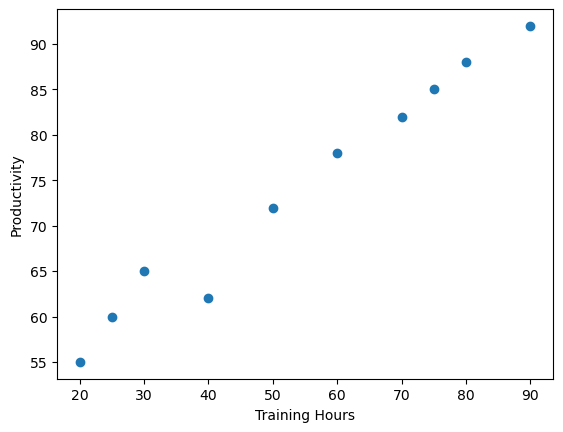

In [78]:
# just visualizing a data point so that we can easily understand
plt.scatter(df["Training Hours"], df["Productivity Score"])
plt.xlabel("Training Hours")
plt.ylabel("Productivity")
plt.show()

In [79]:
training_coef = coef_df[coef_df["Feature"]=="Training Hours"]["Coefficient"].values[0]
working_coef = coef_df[coef_df["Feature"]=="Working Hours"]["Coefficient"].values[0]

print("Training Impact:", training_coef)
print("Working Hours Impact:", working_coef)

Training Impact: 0.26335403726708073
Working Hours Impact: -1.0279503105590064


In [80]:
# as per the above data we can say that we should increase training

In [84]:
# What if Working Hours increase beyond the optimal limit?
cleaned_df.loc[:, "WorkingHours_Sq"] = cleaned_df["Working Hours"] ** 2

X2 = cleaned_df[['Experience (yrs)', 'Training Hours', 'WorkingHours_Sq', 'Projects']]

model2 = LinearRegression()
model2.fit(X2, y)

print(pd.DataFrame({
    "Feature": X2.columns,
    "Coefficient": model2.coef_
}))

            Feature  Coefficient
0  Experience (yrs)    -1.089812
1    Training Hours     0.066897
2   WorkingHours_Sq     0.008154
3          Projects     4.838853


In [85]:
#as per the above data, i don't think we need to increase working hour.

In [86]:
# Can productivity decrease with more experience?
exp_coef = coef_df[coef_df["Feature"]=="Experience (yrs)"]["Coefficient"].values[0]
print("Experience Coefficient:", exp_coef)

Experience Coefficient: -0.2049689440993775


In [87]:
#as per the above data, Yes.

In [88]:
# How to detect overfitting?
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.9999721471743308
Test R2: 0.32398480784235173


In [89]:
# Yes it is overfiting bcoz Train R2 is greater than Test R2

In [92]:
# Suggest one new feature to improve accuracy
# added one dummy extra column
cleaned_df["EngagementScore"] = [7,8,6,9,7,9,6,8,8]

X3 = cleaned_df[['Experience (yrs)', 'Training Hours', 'Working Hours', 'Projects', 'EngagementScore']]

model3 = LinearRegression()
model3.fit(X3, y)

print("New Model R2:", model3.score(X3, y))

New Model R2: 0.9994307249479979


C:\Users\Admin\AppData\Local\Temp\ipykernel_2152\2271516027.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["EngagementScore"] = [7,8,6,9,7,9,6,8,8]
